In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gcmotion as gcm

gcm.utils.reload()

plt.style.use("ggplot")
plt.rcParams["figure.dpi"] = 150

%matplotlib inline

<IPython.core.display.Javascript object>

### Part 1: Particle Initialization and obrit calculation

In this cell we can create multiple particles independently. By setting cwp (current working particle), we chose the particle to proceed. That way we can keep all previous particles in memory and switch cwp at any point.

First we set up the Tokamak configuration, and the particle's initial conditions

In [2]:
R, a   = 6.2, 2  # Major/Minor Radius in [m]
q      = gcm.qfactor.Hypergeometric(R, a)
Bfield = gcm.bfield.LAR(i=0, g=1, B0=5)
Efield = None#gcm.efield.Radial(R, a, q, Ea=75000, minimum=0.9, waist_width=50)

# Create Particle
species = "p"
mu      = 10e-5  # Magnetic moment
theta0  = np.pi / 3
psi0    = 0.5 #0.39  # 0.4513# times psi_wall
z0      = np.pi
Pz0     = -0.025
tspan   = np.linspace(0, 100000, 10000)  # t0, tf, steps

init_cond = [theta0, psi0, z0, Pz0]

# Particle Creation
Electron1 = gcm.Particle(species, mu, init_cond, tspan, R, a, q, Bfield, Efield)
cwp = Electron1

events = [] # [cwp.events("single_theta_period"), cwp.events("single_theta_period")]
cwp.run(events=events)

animate = False

Constants of motion:
	Particle Energy (normalized):	E  = 9.172341e-05
	Particle Energy (eV):		E  = 6.219190e+03 eV
	Particle Energy (J):		E  = 9.964241e-16 J
	Toroidal Momenta:		Pζ = -0.025

Other Quantities:
	Particle of Species:		"p"
	Orbit Type:			Trapped-Confined
	Major Radius:			R = 6.2 meters
	Minor Radius:			α = 2 meters
	Toroidal Flux at wall:		ψ = 0.0520291
	Time unit:			ω = 4.789417e+08 Hz 
	Energy unit:			E = 1.474845e-08 J 

Orbit calculation time: 0.1651s.


### Part 2: Plots

In [3]:
# cwp.plot.tokamak_profile(zoom = [0.2, 1.1])

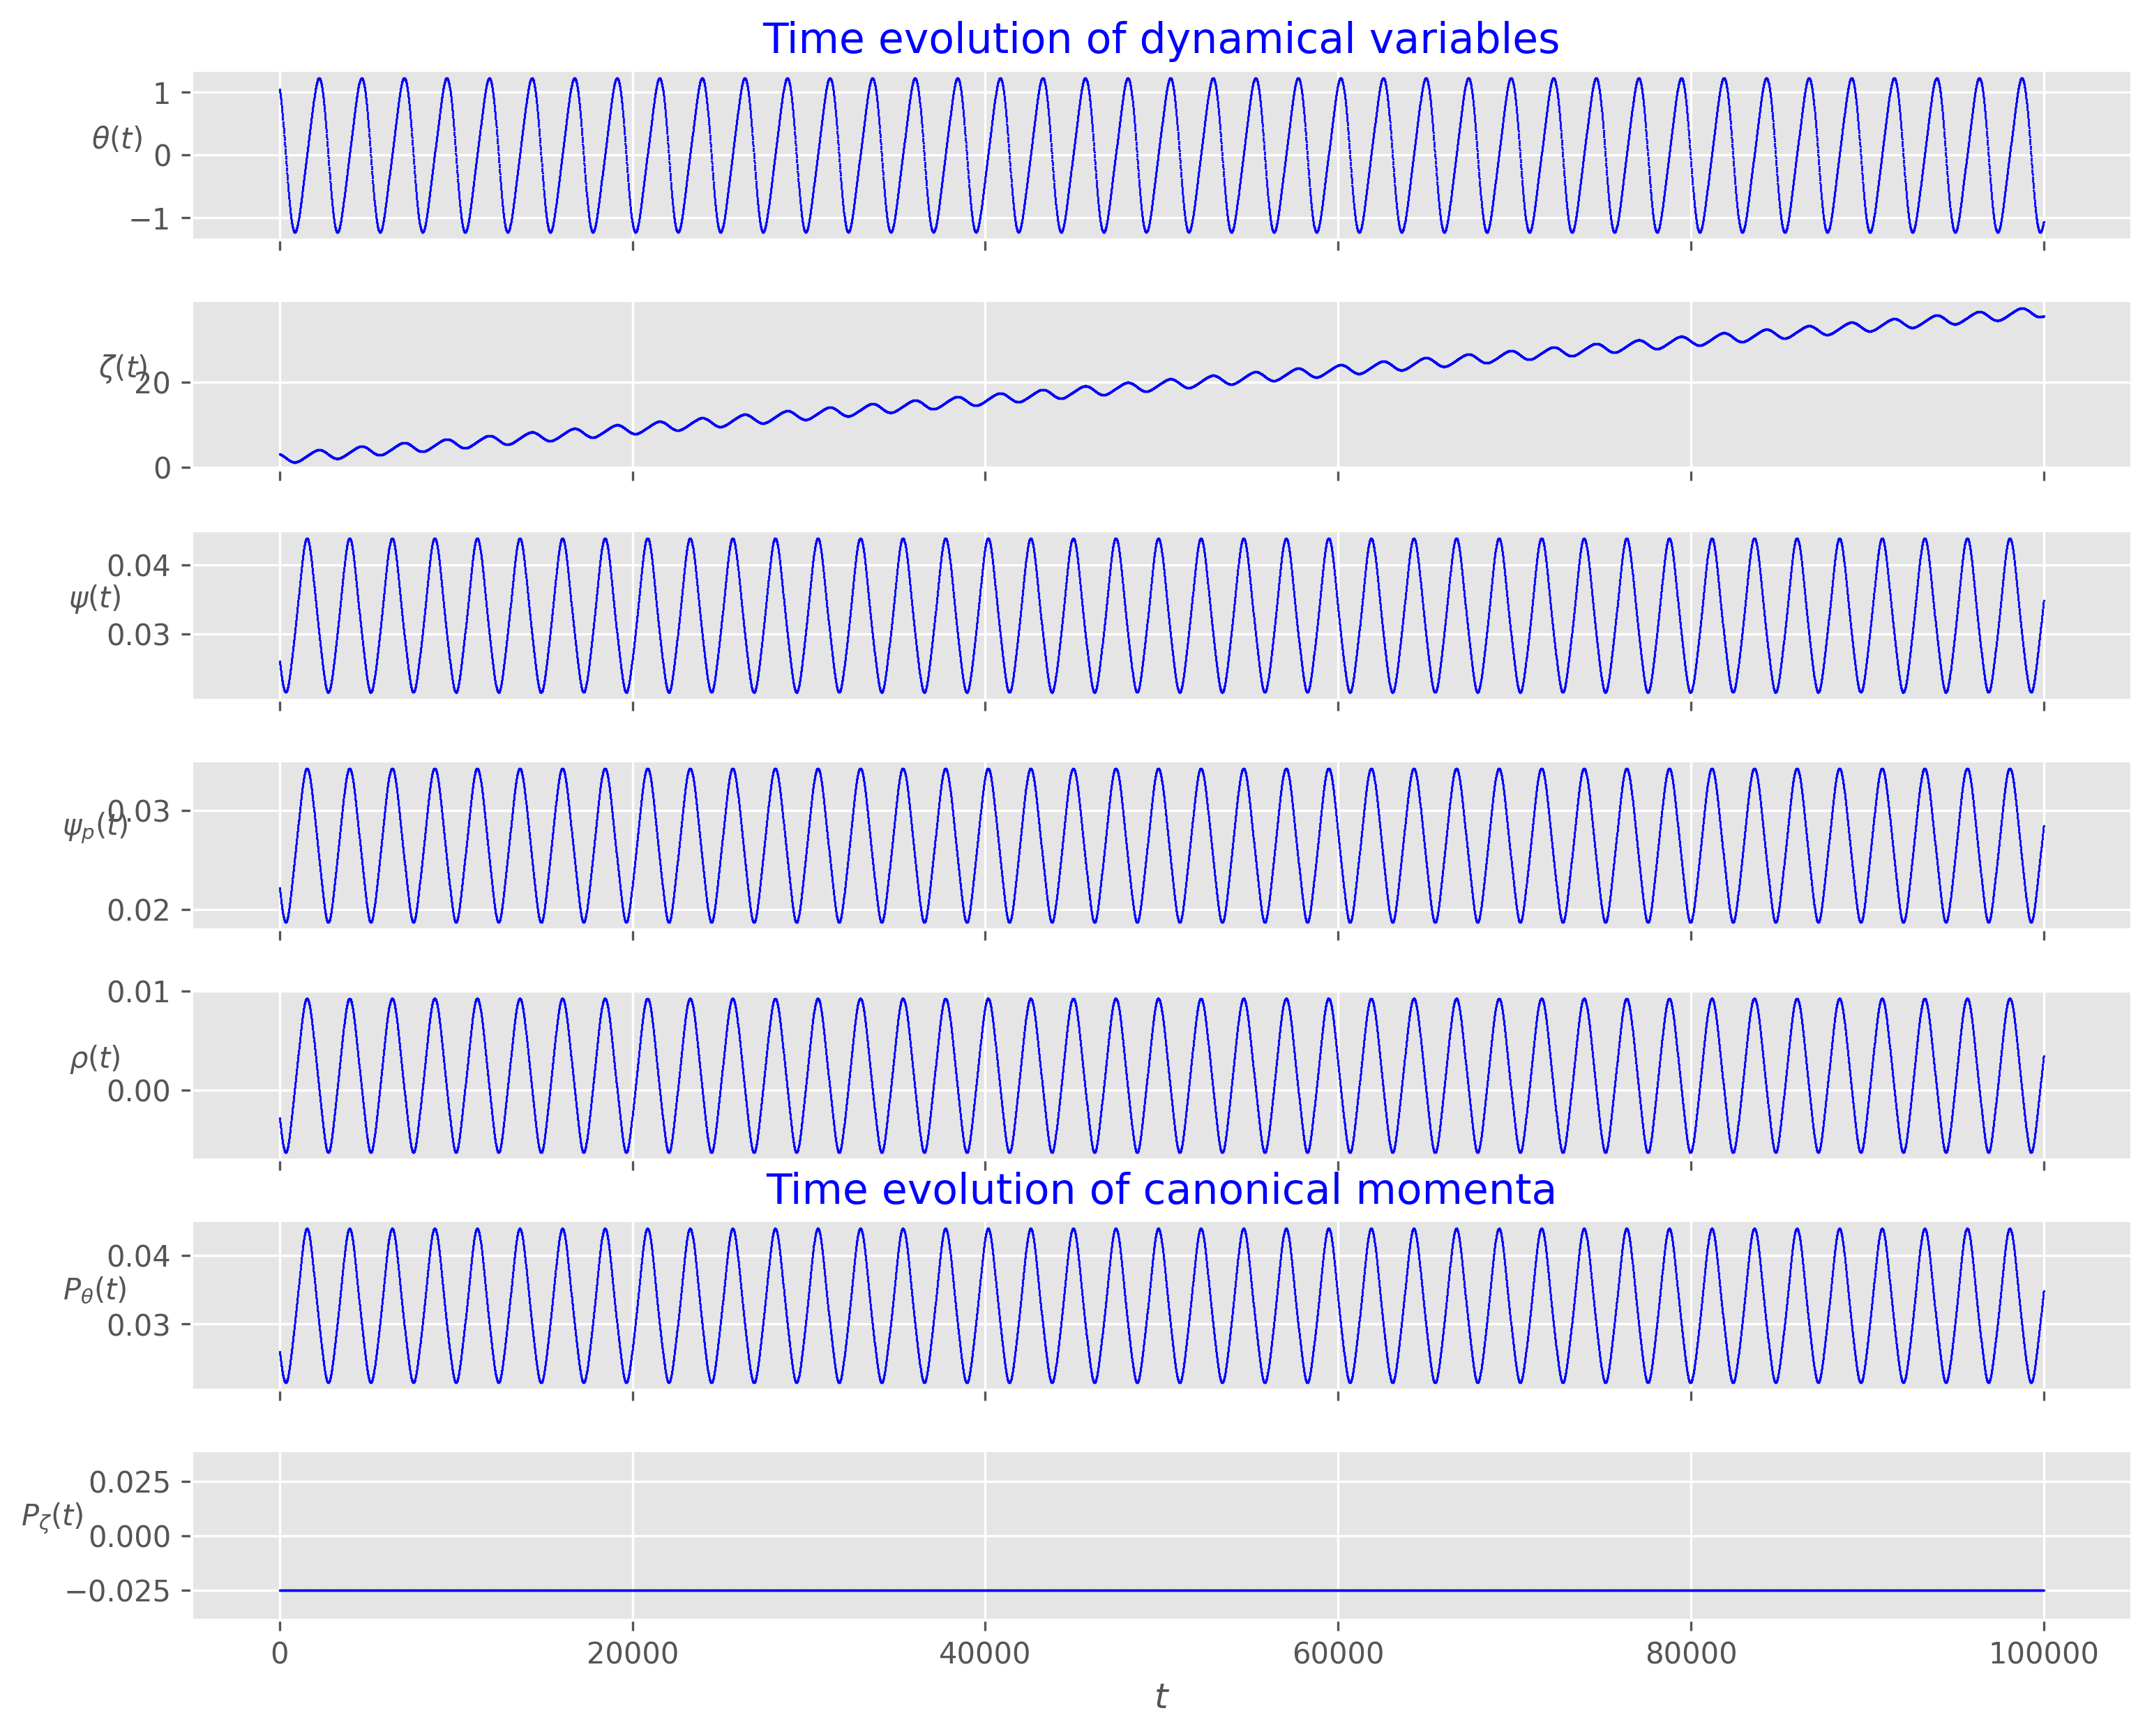

In [4]:
cwp.plot.time_evolution(percentage =100)

### Energy Contour Plots

[2.77412662e-17 5.12270479e-01]


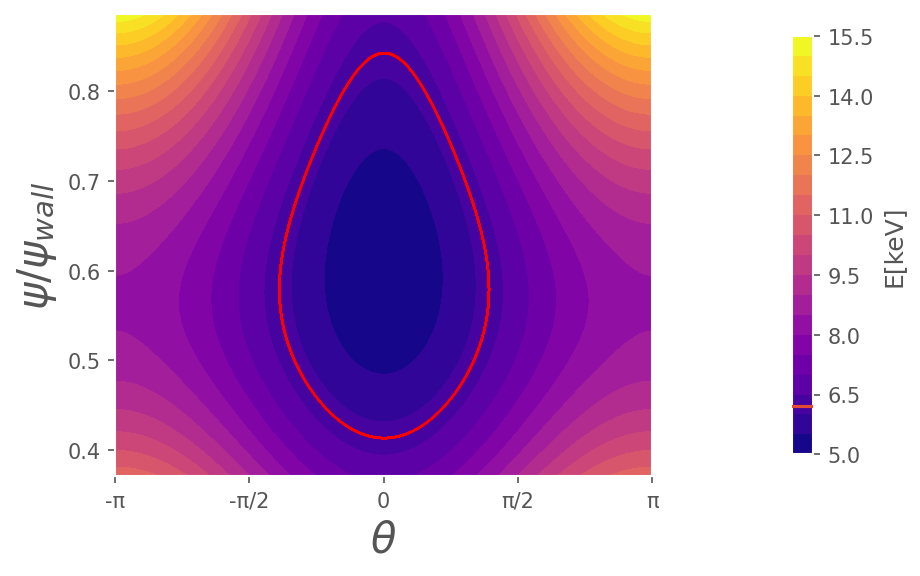

In [5]:
cwp.LAR_fixed_points()
cwp.plot.contour_energy(
    theta_lim = [-np.pi ,np.pi], psi_lim = "auto", 
    plot_drift=True, contour_Phi = True, units = "keV", levels = 20
)

## Orbit types parabolas

As for figuring out if the particle is <ins>L</ins>ost or <ins>C</ins>onfined, we need only to check if its orbit point lies in-between the 2 left parabolas.

In [6]:
# cwp.plot.parabolas()
# cwp.plot.orbit_point()

## Torus Poincare map and 3d Torus orbits

In [7]:
# cwp.plot.torus2d(percentage = 100, truescale=True)

In [8]:
# cwp.plot.torus3d(percentage=1000, truescale=True, 
#                 white_background=True, hd=False,)

In [9]:
# if animate:
#     params = {"percentage": 100, "truescale": True, "min_step": 0.01, "seconds": 300}
#     gcm.animate(cwp, params)

## FFT

In [10]:
# %matplotlib inline 
# # replace "inline" with "qt" for interactive

# trim_params={"periods":100, "steps_per_period":50}
# cwp.freq_analysis(angle="theta", trim_params={})

In [11]:
# %matplotlib inline
# # replace "inline" with "qt" for interactive

# trim_params={"periods":100, "steps_per_period":50}
# cwp.freq_analysis(angle="zeta", trim_params={})